In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from EMDPM.visualization import *
import os
import glob

# Find all PPMI subtyping result files
# Update this path to point to the specific results folder
result_dir = "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/ppmi_stype_unbounded_globalclinical"
pattern = os.path.join(result_dir, "PPMI_subtyping_grid_*.npz")
paths = sorted(glob.glob(pattern))
print(f"Found {len(paths)} result files")

def load_results(paths):
    results = {}
    for path in paths:
        key = os.path.splitext(os.path.basename(path))[0]
        try:
            data = np.load(path, allow_pickle=True)
            results[key] = data
            print(f"Loaded {key} -> keys: {list(data.files)}")
        except Exception as e:
            print(f"Error loading {key}: {e}")
    return results

results = load_results(paths)
print(f"\nTotal loaded: {len(results)} results")


Found 432 result files
Loaded PPMI_subtyping_grid_000_lambda_f0p500_lambda_cog0p010_lambda_scalar0p100_lambda_jsd0p000_lambda_beta0p050 -> keys: ['theta_history', 'cog_history', 'beta_history', 'lse_history', 'assignment_history', 'beta_val', 'candidate', 'f_init', 'train_assignments', 'val_assignments', 'train_ids', 'val_ids', 'final_assignments', 'cluster_f', 'final_scalar_K', 'final_s', 'lambda_f', 'lambda_cog', 'lambda_scalar', 'lambda_jsd', 'lambda_beta', 'param_grid_size']
Loaded PPMI_subtyping_grid_001_lambda_f0p500_lambda_cog0p010_lambda_scalar0p100_lambda_jsd0p000_lambda_beta0p100 -> keys: ['theta_history', 'cog_history', 'beta_history', 'lse_history', 'assignment_history', 'beta_val', 'candidate', 'f_init', 'train_assignments', 'val_assignments', 'train_ids', 'val_ids', 'final_assignments', 'cluster_f', 'final_scalar_K', 'final_s', 'lambda_f', 'lambda_cog', 'lambda_scalar', 'lambda_jsd', 'lambda_beta', 'param_grid_size']
Loaded PPMI_subtyping_grid_002_lambda_f0p500_lambda_cog

In [25]:
# Extract summary statistics for all models
n_biomarkers = 68
summary = []

for cand, data in results.items():
    try:
        # Extract final values
        final_lse = data["lse_history"][-1] if "lse_history" in data.files else np.nan
        
        # Extract cluster parameters (subtyping-specific)
        if "cluster_f" in data.files:
            cluster_f = data["cluster_f"]  # Shape: (n_subtypes, n_biomarkers)
            n_subtypes = cluster_f.shape[0]
        else:
            cluster_f = None
            n_subtypes = 0
        
        final_scalar_K = data["final_scalar_K"] if "final_scalar_K" in data.files else np.nan
        final_s = data["final_s"] if "final_s" in data.files else np.nan
        
        # Extract candidate number
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])
        
        # Extract assignment statistics
        if "final_assignments" in data.files:
            assignments = data["final_assignments"]
            subtype_counts = np.bincount(assignments, minlength=n_subtypes) if n_subtypes > 0 else []
        else:
            subtype_counts = []
        
        summary.append({
            "candidate": candidate_num,
            "key": cand,
            "final_lse": final_lse,
            "n_subtypes": n_subtypes,
            "scalar_K": final_scalar_K,
            "mean_s": np.mean(final_s) if isinstance(final_s, np.ndarray) else final_s,
            "mean_f_cluster0": np.mean(cluster_f[0]) if cluster_f is not None and len(cluster_f) > 0 else np.nan,
            "mean_f_cluster1": np.mean(cluster_f[1]) if cluster_f is not None and len(cluster_f) > 1 else np.nan,
            "subtype0_count": subtype_counts[0] if len(subtype_counts) > 0 else np.nan,
            "subtype1_count": subtype_counts[1] if len(subtype_counts) > 1 else np.nan,
        })
    except Exception as e:
        print(f"Error processing {cand}: {e}")
        continue

summary_df = pd.DataFrame(summary)
# Don't set candidate as index since there may be duplicates
summary_df = summary_df.sort_values("final_lse").reset_index(drop=True)
print("\n=== Summary Statistics (sorted by LSE) ===")
print(summary_df[["candidate", "key", "final_lse", "n_subtypes", "scalar_K", "mean_s"]].head(10))

# Find best model (lowest LSE) - get first row after sorting
best_row = summary_df.iloc[0]
best_idx = best_row["candidate"]
best_key = best_row["key"]

print(f"\n=== Best Model (Lowest LSE) ===")
print(f"Candidate: {best_idx}")
print(f"Key: {best_key}")
print(f"Final LSE: {best_row['final_lse']:.6f}")
print(best_row[["candidate", "key", "final_lse", "n_subtypes", "scalar_K", "mean_s"]])

# Get top 3 models
top3_df = summary_df.head(3)
print(f"\n=== Top 3 Models ===")
print(top3_df[["candidate", "key", "final_lse", "n_subtypes", "scalar_K", "mean_s"]])

# Extract and print best parameters
best_data = results[best_key]
print(f"\n=== Best Model Parameters ===")
if "lambda_f" in best_data.files:
    print(f"lambda_f: {best_data['lambda_f']}")
if "lambda_cog" in best_data.files:
    print(f"lambda_cog: {best_data['lambda_cog']}")
if "lambda_scalar" in best_data.files:
    print(f"lambda_scalar: {best_data['lambda_scalar']}")
if "lambda_jsd" in best_data.files:
    print(f"lambda_jsd: {best_data['lambda_jsd']}")
if "lambda_beta" in best_data.files:
    print(f"lambda_beta: {best_data['lambda_beta']}")
print(f"Final LSE: {best_row['final_lse']:.6f}")



=== Summary Statistics (sorted by LSE) ===
  candidate                                                key   final_lse  \
0       125  PPMI_subtyping_grid_125_lambda_f0p500_lambda_c...  647.813699   
1       121  PPMI_subtyping_grid_121_lambda_f0p500_lambda_c...  675.277731   
2       406  PPMI_subtyping_grid_406_lambda_f1p500_lambda_c...  687.334400   
3       416  PPMI_subtyping_grid_416_lambda_f1p500_lambda_c...  688.292812   
4        44  PPMI_subtyping_grid_044_lambda_f0p500_lambda_c...  689.041696   
5        40  PPMI_subtyping_grid_040_lambda_f0p500_lambda_c...  689.047142   
6        36  PPMI_subtyping_grid_036_lambda_f0p500_lambda_c...  689.048043   
7        32  PPMI_subtyping_grid_032_lambda_f0p500_lambda_c...  689.051247   
8       284  PPMI_subtyping_grid_284_lambda_f1p000_lambda_c...  691.109264   
9        16  PPMI_subtyping_grid_016_lambda_f0p500_lambda_c...  691.676818   

   n_subtypes            scalar_K    mean_s  
0           2                 0.0  0.549925  
1    

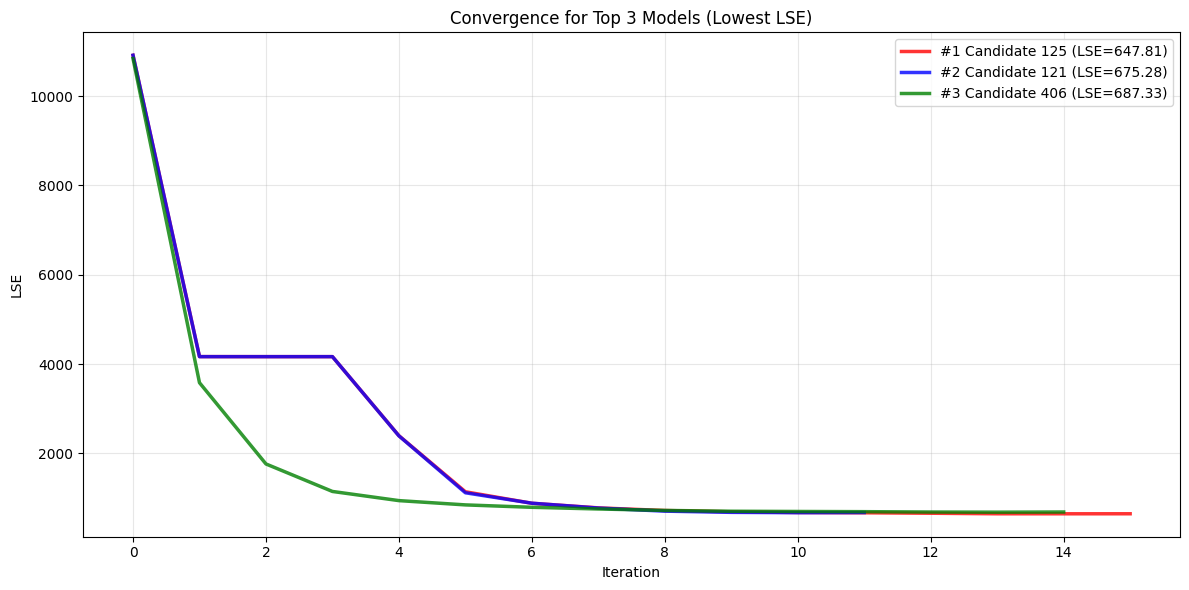

#1 Candidate 125: Min=647.171868, Final=647.813699
#2 Candidate 121: Min=672.195768, Final=675.277731
#3 Candidate 406: Min=683.336904, Final=687.334400


In [26]:
# Plot LSE convergence for TOP 3 models only
plt.figure(figsize=(12, 6))
colors = ['red', 'blue', 'green']

# Get top 3 keys
top3_keys = top3_df["key"].values

for i, key in enumerate(top3_keys):
    if key in results:
        data = results[key]
        if "lse_history" in data.files:
            lse_hist = data["lse_history"]
            candidate_num = data["candidate"] if "candidate" in data.files else int(key.split("_")[-1])
            final_lse = lse_hist[-1]
            label = f"#{i+1} Candidate {candidate_num} (LSE={final_lse:.2f})"
            plt.plot(lse_hist[1:], label=label, 
                    color=colors[i], alpha=0.8, linewidth=2.5)

plt.xlabel("Iteration")
plt.ylabel("LSE")
plt.title("Convergence for Top 3 Models (Lowest LSE)")
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print min LSE for top 3
for i, key in enumerate(top3_keys):
    if key in results:
        data = results[key]
        if "lse_history" in data.files:
            candidate_num = data["candidate"] if "candidate" in data.files else int(key.split("_")[-1])
            min_lse = np.min(data["lse_history"][1:])
            final_lse = data["lse_history"][-1]
            print(f"#{i+1} Candidate {candidate_num}: Min={min_lse:.6f}, Final={final_lse:.6f}")


/tmp/ipykernel_25466/758512606.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


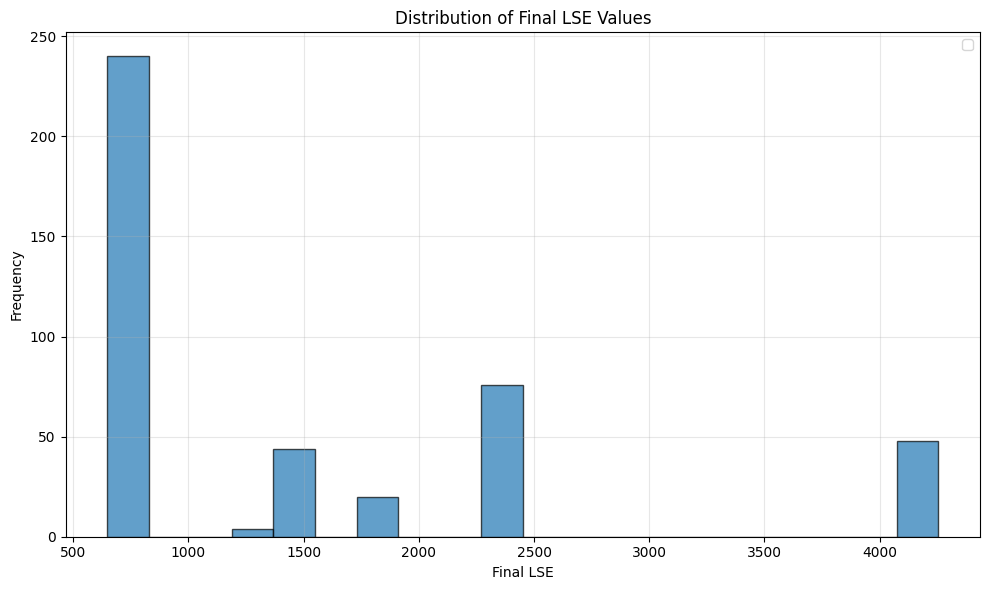

Mean: 1520.661321
Median: 737.498286
Min: 647.813699
Max: 4254.943040
Std: 1143.520735


In [27]:
# Plot LSE distribution
plt.figure(figsize=(10, 6))
final_lses = [data["lse_history"][-1] for data in results.values() if "lse_history" in data.files]
plt.hist(final_lses, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel("Final LSE")
plt.ylabel("Frequency")
plt.title("Distribution of Final LSE Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean: {np.mean(final_lses):.6f}")
print(f"Median: {np.median(final_lses):.6f}")
print(f"Min: {np.min(final_lses):.6f}")
print(f"Max: {np.max(final_lses):.6f}")
print(f"Std: {np.std(final_lses):.6f}")


In [28]:
# Load data for trajectory visualization
from EMDPM.utils import solve_system

df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv")

## remove non-longitudinal observations
print("original size:", df.shape)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

print("after drop na", df.shape)
subj_counts = df['subj_id'].value_counts()
longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])
print("after drop dupes", df.shape)

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs

## connectivity matrix to numpy
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)

# normalization
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

t_max = 40
t_span = np.linspace(0, t_max, int(t_max/0.01))

biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

# Extract arrays for analysis
ids_all = df["subj_id"].to_numpy()
dt_all = df["time"].to_numpy()/12  # convert to years
nhy_all = df["NHY"].to_numpy()
cog_all = df[["MCATOT","TD_score","PIGD_score"]].to_numpy()
df["NSD_STAGE"] = df["NSD_STAGE"].replace({"Not NSD": 0, "2b": 2})
df["NSD_STAGE"] = pd.to_numeric(df["NSD_STAGE"], errors='coerce')
nsd = df["NSD_STAGE"].to_numpy()

print(f"Loaded data: {X_obs.shape}, K: {K.shape}, biomarkers: {len(biomarker_names)}")
print(f"Patients: {len(np.unique(ids_all))}, Observations: {len(ids_all)}")


original size: (880, 250)
after drop na (868, 250)
after drop dupes (504, 250)
Loaded data: (504, 68), K: (68, 68), biomarkers: 68
Patients: 146, Observations: 504


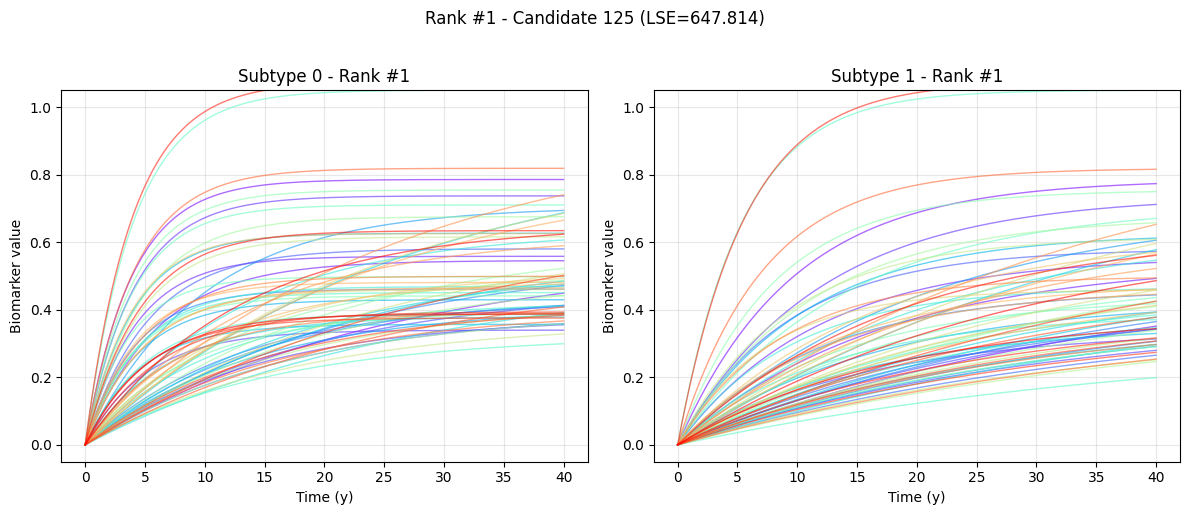

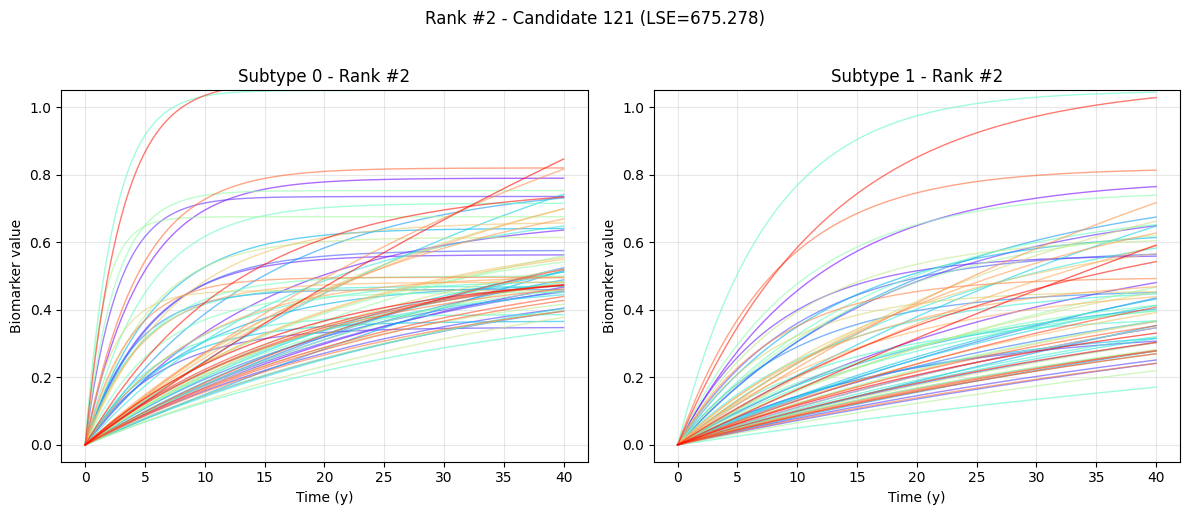

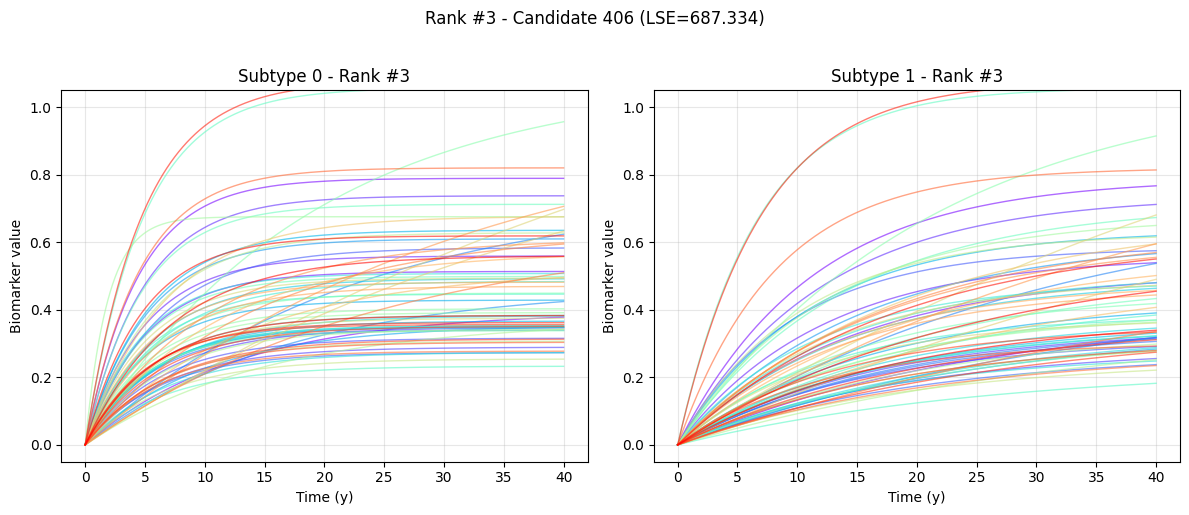

In [29]:
# Plot trajectories for TOP 3 models only
n_biomarkers = len(biomarker_names)

# Get top 3 keys
top3_keys = top3_df["key"].values

for idx, key in enumerate(top3_keys):
    if key not in results:
        continue
        
    data = results[key]
    if "cluster_f" not in data.files:
        continue
        
    cluster_f = data["cluster_f"]
    final_scalar_K = data["final_scalar_K"]
    final_s = data["final_s"]
    final_lse = data["lse_history"][-1] if "lse_history" in data.files else np.nan
    candidate_num = data["candidate"] if "candidate" in data.files else int(key.split("_")[-1])
    
    n_subtypes = cluster_f.shape[0]
    
    # Plot trajectories for each subtype
    fig, axes = plt.subplots(1, n_subtypes, figsize=(6*n_subtypes, 5))
    if n_subtypes == 1:
        axes = [axes]
    
    for subtype in range(n_subtypes):
        f_cluster = cluster_f[subtype]
        x0 = np.zeros(n_biomarkers)
        Xtraj = solve_system(x0, f_cluster, K, t_span, final_scalar_K) * final_s[:, None]
        
        ax = axes[subtype]
        colors = plt.cm.rainbow(np.linspace(0, 1, n_biomarkers))
        for b in range(n_biomarkers):
            ax.plot(t_span, Xtraj[b], color=colors[b], alpha=0.6, linewidth=1.0)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel("Time (y)")
        ax.set_ylabel("Biomarker value")
        ax.set_title(f"Subtype {subtype} - Rank #{idx+1}")
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f"Rank #{idx+1} - Candidate {candidate_num} (LSE={final_lse:.3f})", y=1.02)
    plt.tight_layout()
    plt.show()



=== Rank #1 - Subtype Assignments (Candidate 125) ===
Total patients: 116
Subtype 0: 91 patients (78.4%)
Subtype 1: 25 patients (21.6%)


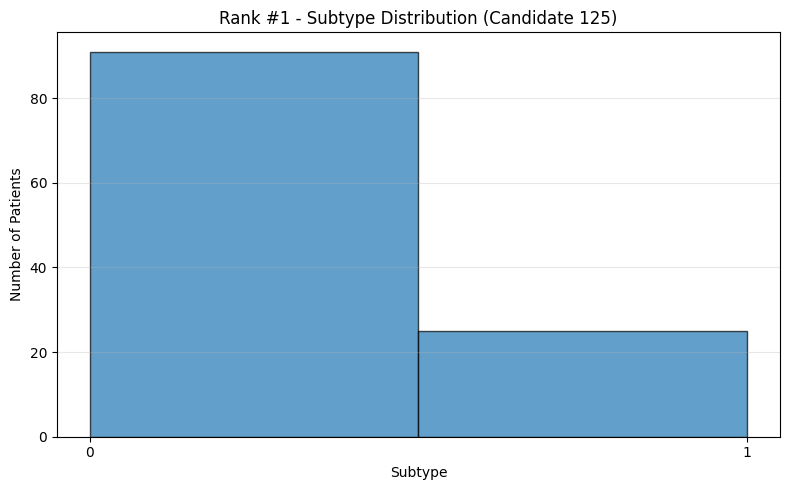

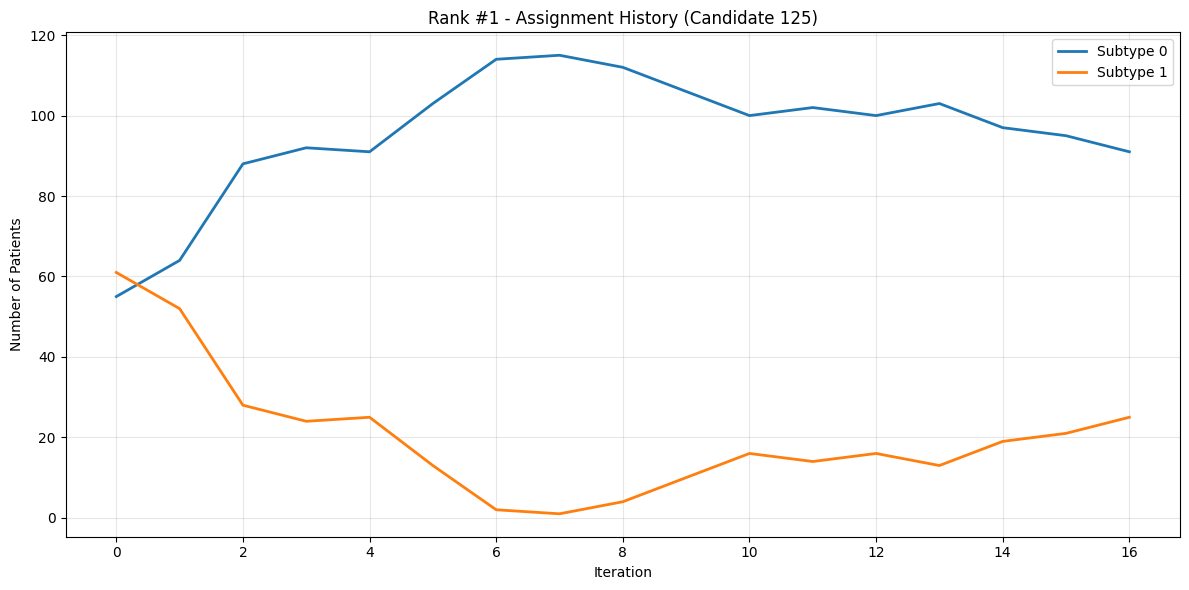


=== Rank #2 - Subtype Assignments (Candidate 121) ===
Total patients: 116
Subtype 0: 107 patients (92.2%)
Subtype 1: 9 patients (7.8%)


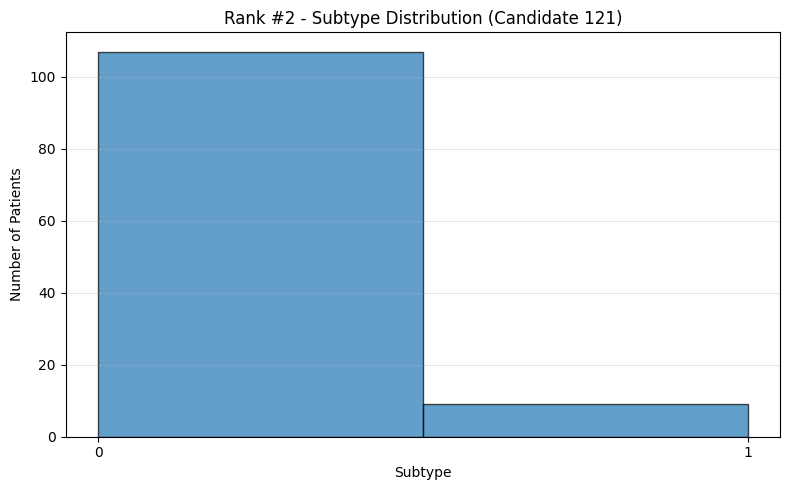

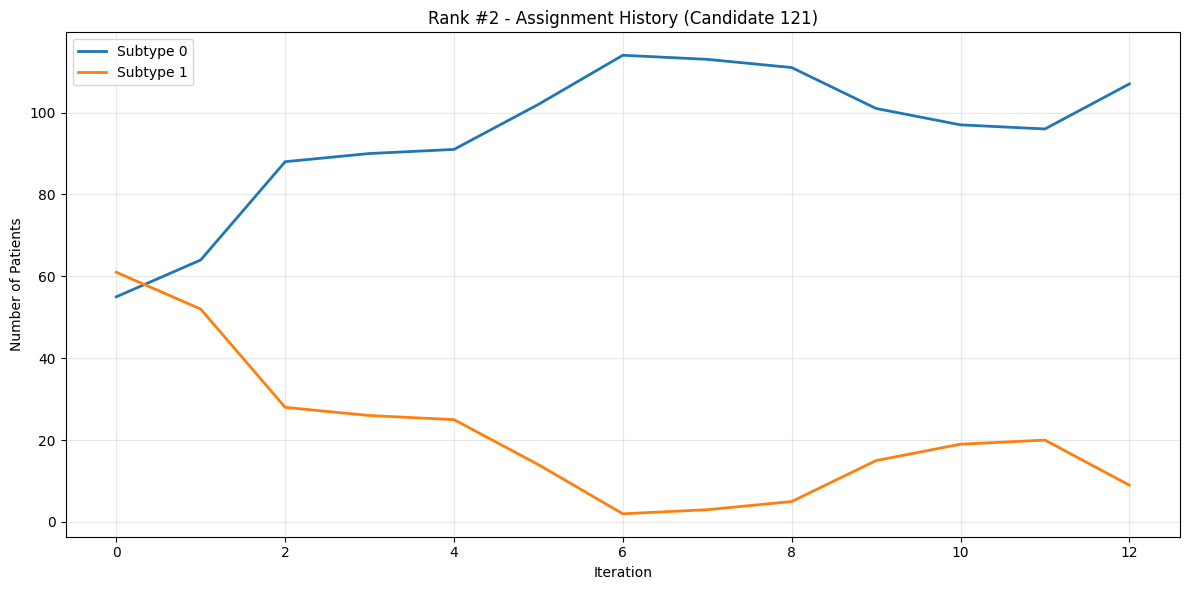


=== Rank #3 - Subtype Assignments (Candidate 406) ===
Total patients: 116
Subtype 0: 88 patients (75.9%)
Subtype 1: 28 patients (24.1%)


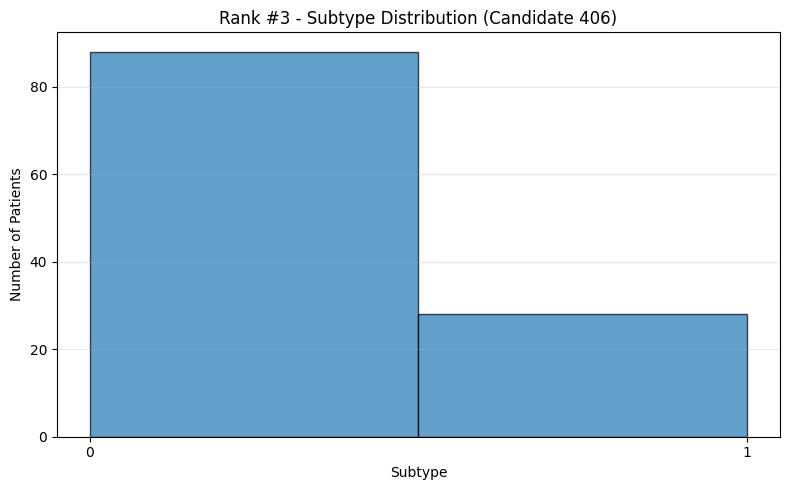

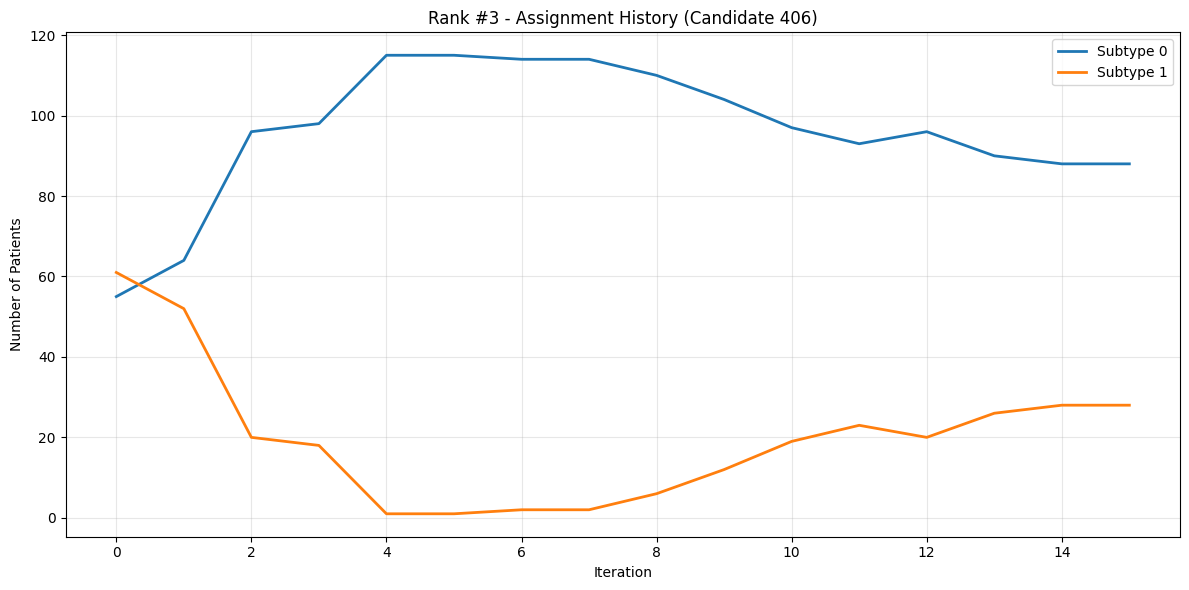

In [30]:
# Analyze subtype assignments for TOP 3 models
top3_keys = top3_df["key"].values

for idx, key in enumerate(top3_keys):
    if key not in results:
        continue
        
    data = results[key]
    candidate_num = data["candidate"] if "candidate" in data.files else int(key.split("_")[-1])
    
    if "final_assignments" in data.files:
        assignments = data["final_assignments"]
        n_subtypes = len(np.unique(assignments))
        
        print(f"\n=== Rank #{idx+1} - Subtype Assignments (Candidate {candidate_num}) ===")
        print(f"Total patients: {len(assignments)}")
        
        for subtype in range(n_subtypes):
            count = np.sum(assignments == subtype)
            pct = 100 * count / len(assignments)
            print(f"Subtype {subtype}: {count} patients ({pct:.1f}%)")
        
        # Plot assignment distribution
        plt.figure(figsize=(8, 5))
        plt.hist(assignments, bins=n_subtypes, edgecolor='black', alpha=0.7)
        plt.xlabel("Subtype")
        plt.ylabel("Number of Patients")
        plt.title(f"Rank #{idx+1} - Subtype Distribution (Candidate {candidate_num})")
        plt.xticks(range(n_subtypes))
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
        
        # Plot assignment history if available
        if "assignment_history" in data.files:
            assignment_hist = data["assignment_history"]
            plt.figure(figsize=(12, 6))
            for subtype in range(n_subtypes):
                counts_per_iter = np.sum(assignment_hist == subtype, axis=0)
                plt.plot(counts_per_iter, label=f"Subtype {subtype}", linewidth=2)
            plt.xlabel("Iteration")
            plt.ylabel("Number of Patients")
            plt.title(f"Rank #{idx+1} - Assignment History (Candidate {candidate_num})")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()



=== Rank #1 - Cluster f Parameters (Candidate 125) ===

Subtype 0:
  Mean f: 0.138381
  Std f: 0.083227
  Min f: 0.033710
  Max f: 0.278612
  Non-zero count: 68/68

Subtype 1:
  Mean f: 0.057886
  Std f: 0.036874
  Min f: 0.021910
  Max f: 0.183699
  Non-zero count: 68/68


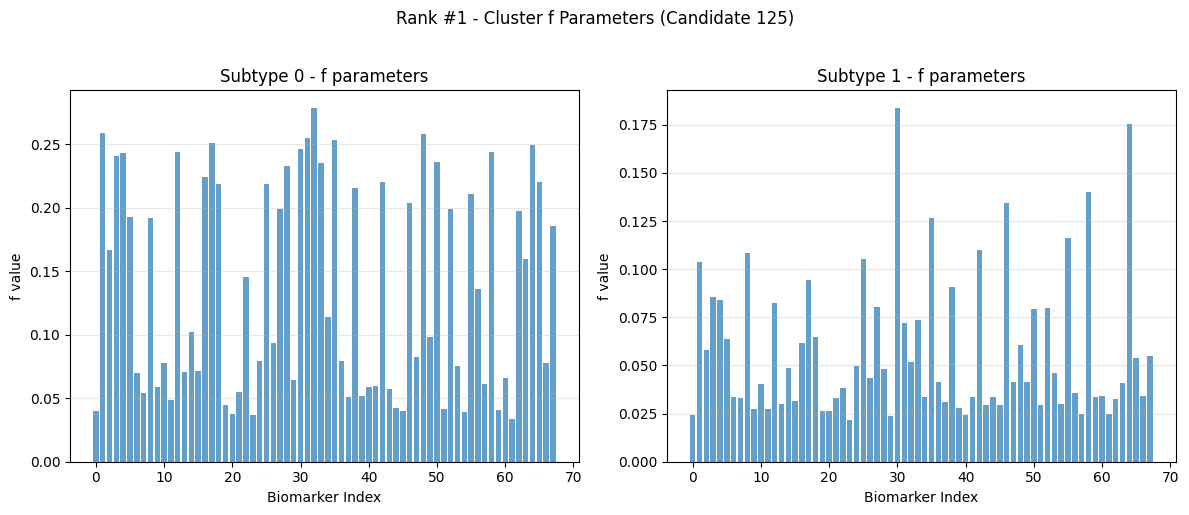


=== Rank #2 - Cluster f Parameters (Candidate 121) ===

Subtype 0:
  Mean f: 0.113877
  Std f: 0.122349
  Min f: 0.009980
  Max f: 0.637610
  Non-zero count: 68/68

Subtype 1:
  Mean f: 0.043073
  Std f: 0.033926
  Min f: 0.006384
  Max f: 0.131725
  Non-zero count: 68/68


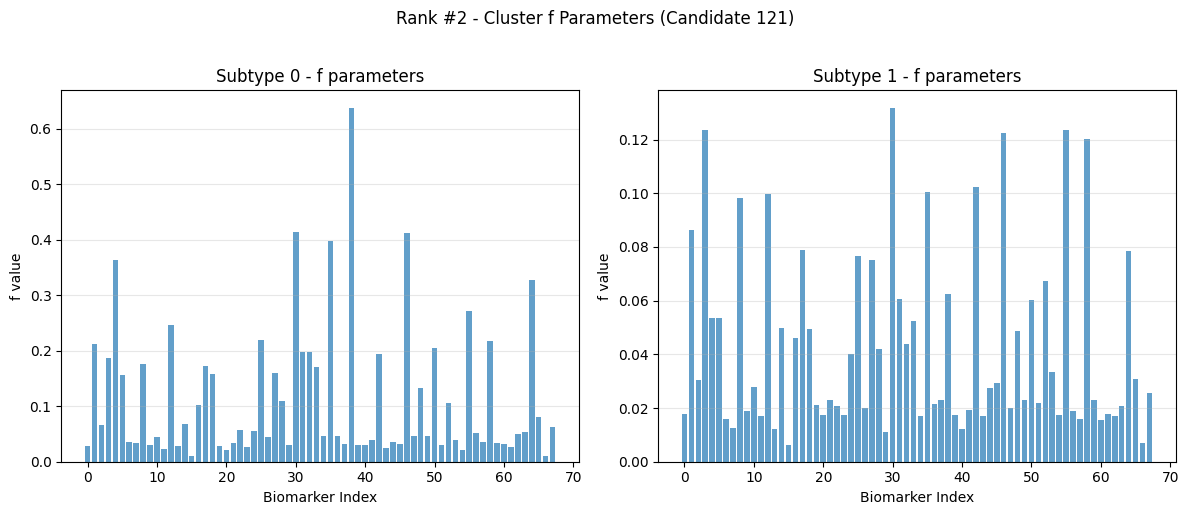


=== Rank #3 - Cluster f Parameters (Candidate 406) ===

Subtype 0:
  Mean f: 0.159350
  Std f: 0.069406
  Min f: 0.016826
  Max f: 0.530605
  Non-zero count: 68/68

Subtype 1:
  Mean f: 0.061868
  Std f: 0.025178
  Min f: 0.015869
  Max f: 0.149403
  Non-zero count: 68/68


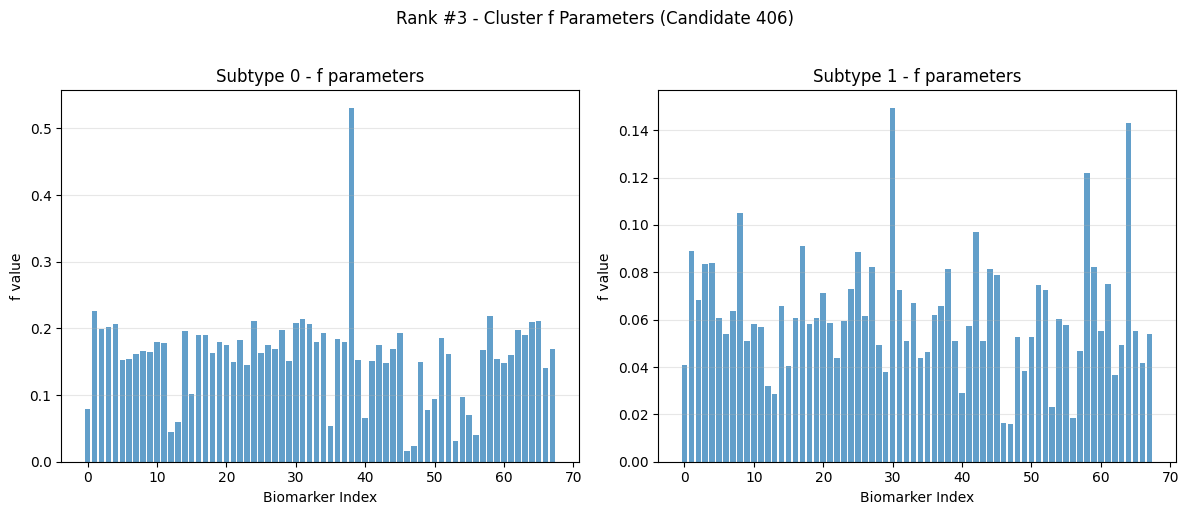

In [31]:
# Compare cluster f parameters for TOP 3 models
top3_keys = top3_df["key"].values

for idx, key in enumerate(top3_keys):
    if key not in results:
        continue
        
    data = results[key]
    candidate_num = data["candidate"] if "candidate" in data.files else int(key.split("_")[-1])
    
    if "cluster_f" in data.files:
        cluster_f = data["cluster_f"]
        n_subtypes = cluster_f.shape[0]
        
        print(f"\n=== Rank #{idx+1} - Cluster f Parameters (Candidate {candidate_num}) ===")
        for subtype in range(n_subtypes):
            f_subtype = cluster_f[subtype]
            print(f"\nSubtype {subtype}:")
            print(f"  Mean f: {np.mean(f_subtype):.6f}")
            print(f"  Std f: {np.std(f_subtype):.6f}")
            print(f"  Min f: {np.min(f_subtype):.6f}")
            print(f"  Max f: {np.max(f_subtype):.6f}")
            print(f"  Non-zero count: {np.sum(f_subtype > 1e-6)}/{len(f_subtype)}")
        
        # Visualize f parameters
        fig, axes = plt.subplots(1, n_subtypes, figsize=(6*n_subtypes, 5))
        if n_subtypes == 1:
            axes = [axes]
        
        for subtype in range(n_subtypes):
            ax = axes[subtype]
            f_subtype = cluster_f[subtype]
            ax.bar(range(len(f_subtype)), f_subtype, alpha=0.7)
            ax.set_xlabel("Biomarker Index")
            ax.set_ylabel("f value")
            ax.set_title(f"Subtype {subtype} - f parameters")
            ax.grid(True, alpha=0.3, axis='y')
        
        plt.suptitle(f"Rank #{idx+1} - Cluster f Parameters (Candidate {candidate_num})", y=1.02)
        plt.tight_layout()
        plt.show()


In [32]:
# Beta analysis for best model
from scipy.stats import kendalltau

# Load best model data
best_data = results[best_key]
beta_final = best_data["beta_history"][:, -1]
assignments = best_data["final_assignments"]

# Get train and val IDs
train_ids = best_data["train_ids"]
val_ids = best_data["val_ids"] if "val_ids" in best_data.files else []

# Combine train and val betas
beta_val = best_data["beta_val"] if "beta_val" in best_data.files else []
all_betas = np.concatenate([beta_final, beta_val]) if len(beta_val) > 0 else beta_final
all_ids = np.concatenate([train_ids, val_ids]) if len(val_ids) > 0 else train_ids

# Create mapping from patient ID to beta
pid_to_beta = {pid: all_betas[i] for i, pid in enumerate(all_ids)}

# Get assignments for all patients (train + val)
train_assignments = best_data["final_assignments"]
val_assignments = best_data["val_assignments"] if "val_assignments" in best_data.files else []
all_assignments = np.concatenate([train_assignments, val_assignments]) if len(val_assignments) > 0 else train_assignments

# Map assignments to patient IDs
pid_to_assignment = {pid: all_assignments[i] for i, pid in enumerate(all_ids)}

# Get beta values aligned with df (ids_all, dt_all, nhy_all, nsd defined in cell 4)
beta_all = np.array([pid_to_beta.get(pid, np.nan) for pid in ids_all])
assignment_all = np.array([pid_to_assignment.get(pid, -1) for pid in ids_all])

# Filter out NaN betas
valid_mask = ~np.isnan(beta_all) & (assignment_all >= 0)
beta_valid = beta_all[valid_mask]
assignment_valid = assignment_all[valid_mask]
ids_valid = ids_all[valid_mask]
nhy_valid = nhy_all[valid_mask]
nsd_valid = nsd[valid_mask]
dt_valid = dt_all[valid_mask]

print(f"Valid patients: {len(beta_valid)}")
print(f"Subtype 0: {np.sum(assignment_valid == 0)}")
print(f"Subtype 1: {np.sum(assignment_valid == 1)}")


Valid patients: 504
Subtype 0: 392
Subtype 1: 112


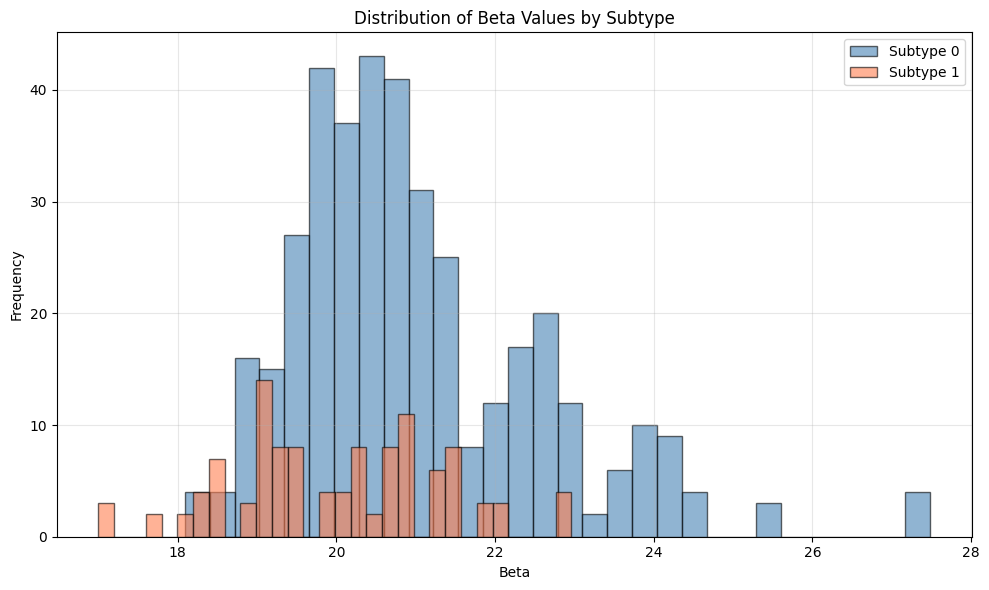


Subtype 0:
  Count: 392
  Mean: 21.0091
  Median: 20.6663
  Std: 1.5948
  Range: [18.0912, 27.4856]

Subtype 1:
  Count: 112
  Mean: 19.9895
  Median: 20.1023
  Std: 1.3022
  Range: [17.0017, 22.9614]


In [33]:
# Histogram of betas by subtype
plt.figure(figsize=(10, 6))
n_subtypes = len(np.unique(assignment_valid))
colors = ['steelblue', 'coral']

for subtype in range(n_subtypes):
    beta_subtype = beta_valid[assignment_valid == subtype]
    plt.hist(beta_subtype, bins=30, alpha=0.6, label=f'Subtype {subtype}', 
             color=colors[subtype], edgecolor='black')
    
plt.xlabel("Beta")
plt.ylabel("Frequency")
plt.title("Distribution of Beta Values by Subtype")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
for subtype in range(n_subtypes):
    beta_subtype = beta_valid[assignment_valid == subtype]
    print(f"\nSubtype {subtype}:")
    print(f"  Count: {len(beta_subtype)}")
    print(f"  Mean: {np.mean(beta_subtype):.4f}")
    print(f"  Median: {np.median(beta_subtype):.4f}")
    print(f"  Std: {np.std(beta_subtype):.4f}")
    print(f"  Range: [{np.min(beta_subtype):.4f}, {np.max(beta_subtype):.4f}]")


In [34]:
# Spaghetti plots: Beta vs NHY and NSD by subtype
# Create patient list for plotting
def create_patient_list_for_plotting(ids, dt, nhy, nsd, pid_to_beta_dict, pid_to_assignment_dict):
    unique_ids = np.unique(ids)
    patient_list = []
    for pid in unique_ids:
        mask = (ids == pid)
        if np.sum(mask) < 2:  # Need at least 2 observations
            continue
        patient_list.append({
            "id": pid,
            "dt": dt[mask],
            "beta": pid_to_beta_dict.get(pid, np.nan),
            "nhy": nhy[mask],
            "nsd": nsd[mask],
            "subtype": pid_to_assignment_dict.get(pid, -1)
        })
    return patient_list

# Create patient list using valid data
X_patients = create_patient_list_for_plotting(ids_valid, dt_valid, nhy_valid, nsd_valid,
                                               pid_to_beta, pid_to_assignment)

# Filter to valid patients
X_patients_valid = [p for p in X_patients if p["subtype"] >= 0 and not np.isnan(p["beta"])]

# Separate by subtype
X_by_subtype = {s: [p for p in X_patients_valid if p["subtype"] == s] for s in range(n_subtypes)}


/home/dsemchin/Progression_models_simulations/EMDPM/visualization.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="beta", palette="plasma", inner="box")


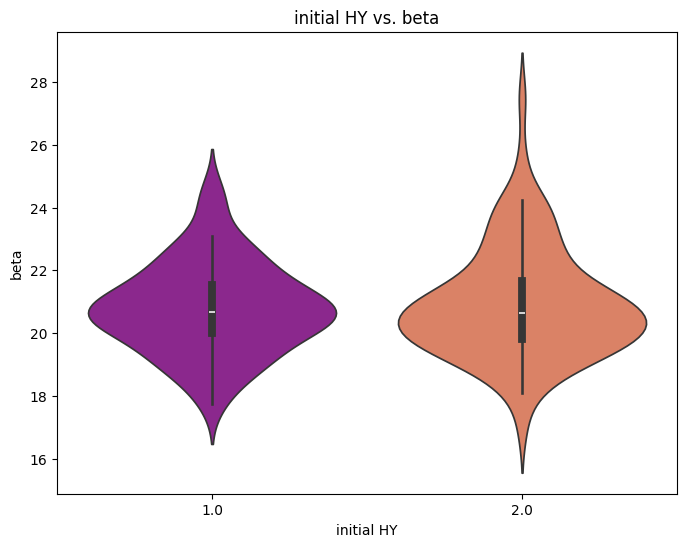

/home/dsemchin/Progression_models_simulations/EMDPM/visualization.py:859: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="NHY", y="t_ij", palette="plasma", inner="box")


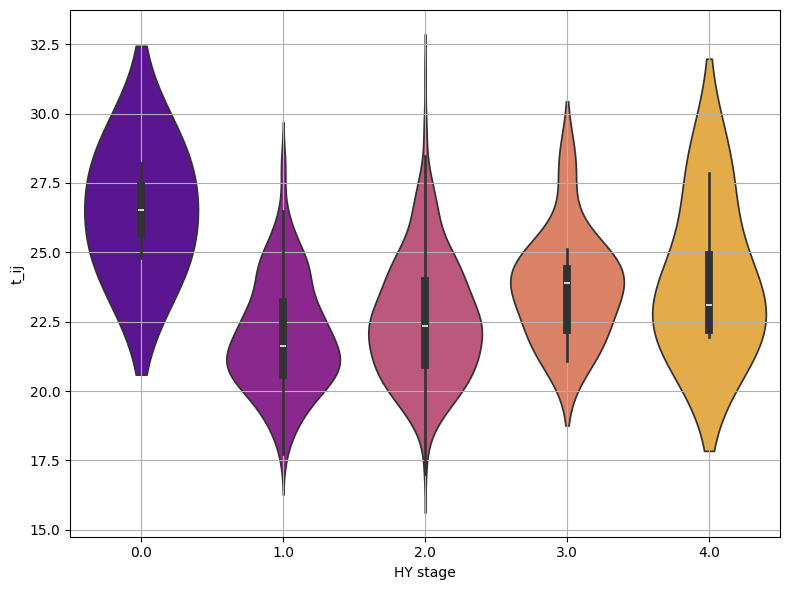

/tmp/ipykernel_25466/2851132747.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_nsd, x="NSD", y="beta", palette="plasma", inner="box")


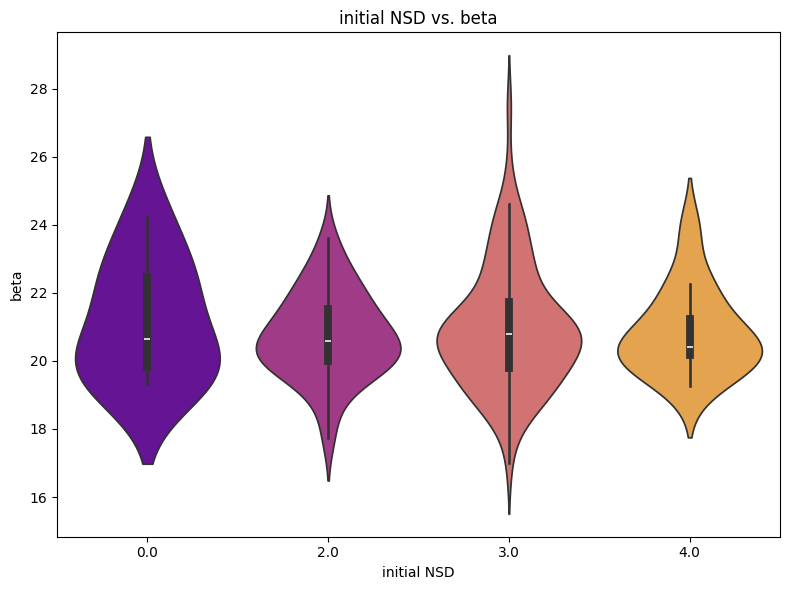

/tmp/ipykernel_25466/2851132747.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_nsd_tij, x="NSD", y="t_ij", palette="plasma", inner="box")


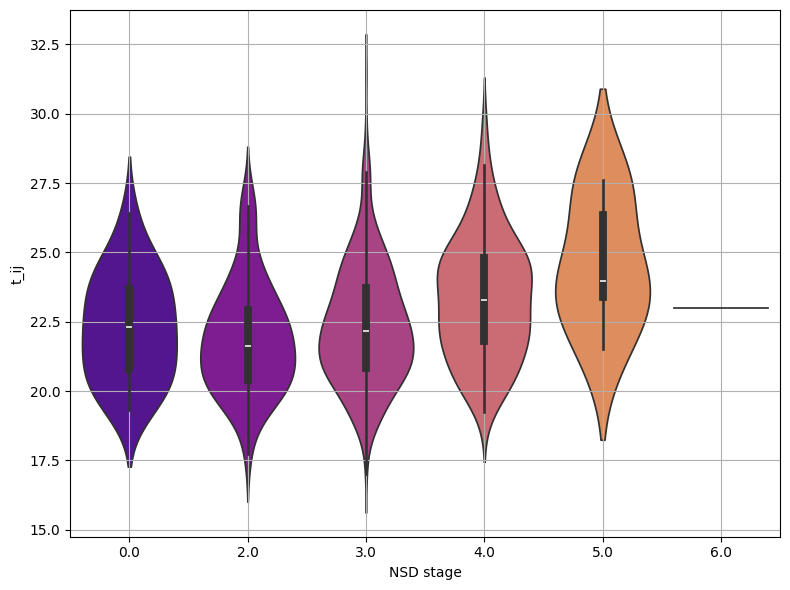

In [35]:
# Violin plots
from EMDPM.visualization import plot_violin_nhy_vs_beta, plot_violin_nhy_vs_tij

# Create mapping for violin plots
unique_ids_valid = np.unique(ids_valid)
pid_to_beta_violin = {pid: beta_valid[i] for i, pid in enumerate(unique_ids_valid)}

# Violin plot: NHY vs Beta
plot_violin_nhy_vs_beta(ids=ids_valid, dt=dt_valid, nhy=nhy_valid, beta=beta_valid)

# Violin plot: NHY vs t_ij (dt + beta)
plot_violin_nhy_vs_tij(dt=dt_valid, ids=ids_valid, beta=beta_valid, nhy=nhy_valid)

# Violin plot: NSD vs Beta (using same function structure)
unique_ids_valid = np.unique(ids_valid)
pair_nsd = []
pid_to_beta_nsd = {pid: beta_valid[i] for i, pid in enumerate(unique_ids_valid)}

for pid in unique_ids_valid:
    mask = (ids_valid == pid)
    dt_i = dt_valid[mask]
    nsd_i = nsd_valid[mask]
    idx_min_dt = np.argmin(dt_i)
    nsd_first = nsd_i[idx_min_dt] if len(nsd_i) > 0 else np.nan
    beta_i = pid_to_beta_nsd.get(pid, np.nan)
    if not np.isnan(nsd_first) and not np.isnan(beta_i):
        pair_nsd.append({"NSD": nsd_first, "beta": beta_i})

df_nsd = pd.DataFrame(pair_nsd).dropna()

if len(df_nsd) > 0:
    plt.figure(figsize=(8, 6))
    sns.violinplot(data=df_nsd, x="NSD", y="beta", palette="plasma", inner="box")
    plt.title("initial NSD vs. beta")
    plt.xlabel("initial NSD")
    plt.ylabel("beta")
    plt.tight_layout()
    plt.show()

# Violin plot: NSD vs t_ij
pair_nsd_tij = []
pid_to_index_nsd = {pid: idx for idx, pid in enumerate(unique_ids_valid)}
t_ij_nsd = np.array([dt_i + beta_valid[pid_to_index_nsd[pid]] 
                     for dt_i, pid in zip(dt_valid, ids_valid)])

df_nsd_tij = pd.DataFrame({
    "t_ij": t_ij_nsd,
    "NSD": nsd_valid
}).dropna()

if len(df_nsd_tij) > 0:
    plt.figure(figsize=(8, 6))
    sns.violinplot(data=df_nsd_tij, x="NSD", y="t_ij", palette="plasma", inner="box")
    plt.xlabel("NSD stage")
    plt.ylabel("t_ij")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [36]:
# Kendall tau correlations
from scipy.stats import kendalltau

# Compute t_ij = dt + beta for all observations
unique_ids_valid = np.unique(ids_valid)
pid_to_index_tau = {pid: idx for idx, pid in enumerate(unique_ids_valid)}
t_ij_all = np.array([dt_i + beta_valid[pid_to_index_tau[pid]] 
                    for dt_i, pid in zip(dt_valid, ids_valid)])

# Overall correlations
print("=== Overall Correlations ===")
tau_beta_nhy, p_beta_nhy = kendalltau(beta_valid, nhy_valid)
tau_tij_nhy, p_tij_nhy = kendalltau(t_ij_all, nhy_valid)
tau_beta_nsd, p_beta_nsd = kendalltau(beta_valid[~np.isnan(nsd_valid)], 
                                      nsd_valid[~np.isnan(nsd_valid)])
tau_tij_nsd, p_tij_nsd = kendalltau(t_ij_all[~np.isnan(nsd_valid)], 
                                    nsd_valid[~np.isnan(nsd_valid)])

print(f"Beta vs NHY: tau={tau_beta_nhy:.4f}, p={p_beta_nhy:.4f}")
print(f"t_ij vs NHY: tau={tau_tij_nhy:.4f}, p={p_tij_nhy:.4f}")
print(f"Beta vs NSD: tau={tau_beta_nsd:.4f}, p={p_beta_nsd:.4f}")
print(f"t_ij vs NSD: tau={tau_tij_nsd:.4f}, p={p_tij_nsd:.4f}")

# By subtype
print("\n=== Correlations by Subtype ===")
for subtype in range(n_subtypes):
    mask_subtype = assignment_valid == subtype
    beta_subtype = beta_valid[mask_subtype]
    nhy_subtype = nhy_valid[mask_subtype]
    nsd_subtype = nsd_valid[mask_subtype]
    t_ij_subtype = t_ij_all[mask_subtype]
    
    print(f"\nSubtype {subtype} (n={len(beta_subtype)}):")
    tau_beta_nhy_sub, p_beta_nhy_sub = kendalltau(beta_subtype, nhy_subtype)
    tau_tij_nhy_sub, p_tij_nhy_sub = kendalltau(t_ij_subtype, nhy_subtype)
    
    valid_nsd_mask = ~np.isnan(nsd_subtype)
    if np.sum(valid_nsd_mask) > 0:
        tau_beta_nsd_sub, p_beta_nsd_sub = kendalltau(beta_subtype[valid_nsd_mask], 
                                                      nsd_subtype[valid_nsd_mask])
        tau_tij_nsd_sub, p_tij_nsd_sub = kendalltau(t_ij_subtype[valid_nsd_mask], 
                                                    nsd_subtype[valid_nsd_mask])
        print(f"  Beta vs NHY: tau={tau_beta_nhy_sub:.4f}, p={p_beta_nhy_sub:.4f}")
        print(f"  t_ij vs NHY: tau={tau_tij_nhy_sub:.4f}, p={p_tij_nhy_sub:.4f}")
        print(f"  Beta vs NSD: tau={tau_beta_nsd_sub:.4f}, p={p_beta_nsd_sub:.4f}")
        print(f"  t_ij vs NSD: tau={tau_tij_nsd_sub:.4f}, p={p_tij_nsd_sub:.4f}")
    else:
        print(f"  Beta vs NHY: tau={tau_beta_nhy_sub:.4f}, p={p_beta_nhy_sub:.4f}")
        print(f"  t_ij vs NHY: tau={tau_tij_nhy_sub:.4f}, p={p_tij_nhy_sub:.4f}")
        print(f"  NSD: insufficient data")


=== Overall Correlations ===
Beta vs NHY: tau=0.2118, p=0.0000
t_ij vs NHY: tau=0.1159, p=0.0012
Beta vs NSD: tau=0.1365, p=0.0001
t_ij vs NSD: tau=0.1465, p=0.0000

=== Correlations by Subtype ===

Subtype 0 (n=392):
  Beta vs NHY: tau=0.2175, p=0.0000
  t_ij vs NHY: tau=0.0939, p=0.0211
  Beta vs NSD: tau=0.1161, p=0.0037
  t_ij vs NSD: tau=0.1594, p=0.0001

Subtype 1 (n=112):
  Beta vs NHY: tau=0.1601, p=0.0388
  t_ij vs NHY: tau=0.2100, p=0.0061
  Beta vs NSD: tau=0.2503, p=0.0009
  t_ij vs NSD: tau=0.1007, p=0.1753


In [37]:
# Spaghetti plots for best model - ROI regions only
# Define ROI and biomarker names
biomarker_names = ['L_bankssts_thickavg', 'L_caudalanteriorcingulate_thickavg', 'L_caudalmiddlefrontal_thickavg', 'L_cuneus_thickavg',
                   'L_entorhinal_thickavg', 'L_fusiform_thickavg', 'L_inferiorparietal_thickavg', 'L_inferiortemporal_thickavg',
                   'L_isthmuscingulate_thickavg', 'L_lateraloccipital_thickavg', 'L_lateralorbitofrontal_thickavg',
                   'L_lingual_thickavg', 'L_medialorbitofrontal_thickavg', 'L_middletemporal_thickavg', 'L_parahippocampal_thickavg',
                   'L_paracentral_thickavg', 'L_parsopercularis_thickavg', 'L_parsorbitalis_thickavg', 'L_parstriangularis_thickavg',
                   'L_pericalcarine_thickavg', 'L_postcentral_thickavg', 'L_posteriorcingulate_thickavg', 'L_precentral_thickavg',
                   'L_precuneus_thickavg', 'L_rostralanteriorcingulate_thickavg', 'L_rostralmiddlefrontal_thickavg', 'L_superiorfrontal_thickavg',
                   'L_superiorparietal_thickavg', 'L_superiortemporal_thickavg', 'L_supramarginal_thickavg', 'L_frontalpole_thickavg',
                   'L_temporalpole_thickavg', 'L_transversetemporal_thickavg', 'L_insula_thickavg', 'R_bankssts_thickavg', 'R_caudalanteriorcingulate_thickavg',
                   'R_caudalmiddlefrontal_thickavg', 'R_cuneus_thickavg', 'R_entorhinal_thickavg', 'R_fusiform_thickavg', 'R_inferiorparietal_thickavg',
                   'R_inferiortemporal_thickavg', 'R_isthmuscingulate_thickavg', 'R_lateraloccipital_thickavg', 'R_lateralorbitofrontal_thickavg',
                   'R_lingual_thickavg', 'R_medialorbitofrontal_thickavg', 'R_middletemporal_thickavg', 'R_parahippocampal_thickavg', 'R_paracentral_thickavg',
                   'R_parsopercularis_thickavg', 'R_parsorbitalis_thickavg', 'R_parstriangularis_thickavg', 'R_pericalcarine_thickavg', 'R_postcentral_thickavg',
                   'R_posteriorcingulate_thickavg', 'R_precentral_thickavg', 'R_precuneus_thickavg', 'R_rostralanteriorcingulate_thickavg',
                   'R_rostralmiddlefrontal_thickavg', 'R_superiorfrontal_thickavg', 'R_superiorparietal_thickavg', 'R_superiortemporal_thickavg',
                   'R_supramarginal_thickavg', 'R_frontalpole_thickavg', 'R_temporalpole_thickavg', 'R_transversetemporal_thickavg', 'R_insula_thickavg']

ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

# Get best model data
best_data = results[best_key]
beta_final = best_data["beta_history"][:, -1]
train_ids = best_data["train_ids"]
val_ids = best_data["val_ids"] if "val_ids" in best_data.files else []
beta_val = best_data["beta_val"] if "beta_val" in best_data.files else []

# Create pid_to_beta mapping
all_ids_list = list(train_ids) + list(val_ids)
all_betas_list = list(beta_final) + list(beta_val)
pid_to_beta_best = {pid: beta for pid, beta in zip(all_ids_list, all_betas_list)}

# Get beta values aligned with ids_all
beta_all_best = np.array([pid_to_beta_best.get(pid, np.nan) for pid in ids_all])

# Filter to valid patients (those in train or val set)
valid_patients_mask = np.array([pid in pid_to_beta_best for pid in ids_all])
ids_best = ids_all[valid_patients_mask]
dt_best = dt_all[valid_patients_mask]
X_obs_best = X_obs[valid_patients_mask]
nhy_best = nhy_all[valid_patients_mask]
nsd_best = nsd[valid_patients_mask]
beta_best = beta_all_best[valid_patients_mask]

# Get model trajectory for best model
theta_hist = best_data["theta_history"]
final_theta = theta_hist[:, -1]
final_f = final_theta[:n_biomarkers]
final_s = final_theta[n_biomarkers:2*n_biomarkers]
final_sK = final_theta[-1]

x0 = np.zeros(n_biomarkers)
Xtraj_best = solve_system(x0, final_f, K, t_span, final_sK) * final_s[:, None]

print(f"Best model: {best_key}")
print(f"Patients in plot: {len(np.unique(ids_best))}")
print(f"Observations: {len(ids_best)}")


Best model: PPMI_subtyping_grid_125_lambda_f0p500_lambda_cog0p100_lambda_scalar0p300_lambda_jsd0p150_lambda_beta0p100
Patients in plot: 146
Observations: 504


/home/dsemchin/Progression_models_simulations/EMDPM/visualization.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1500x700 with 0 Axes>

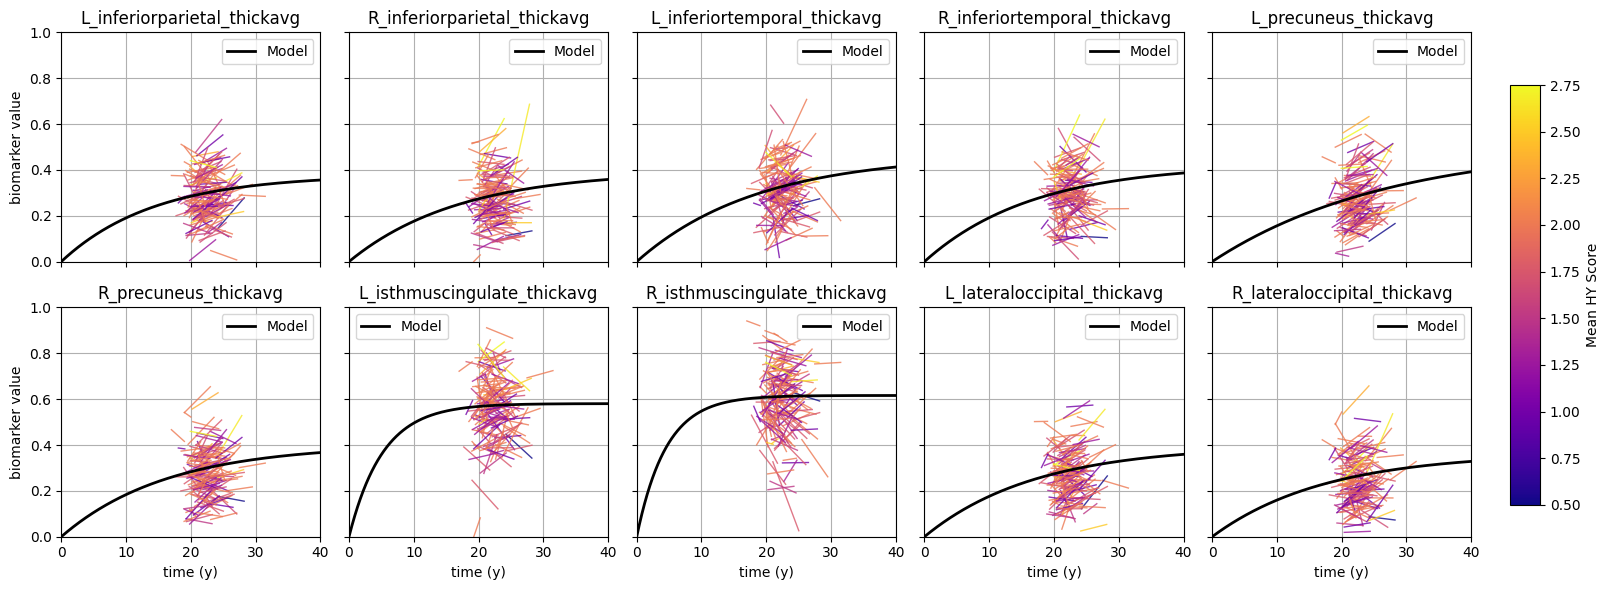

<Figure size 640x480 with 0 Axes>

In [38]:
# Spaghetti plot for NHY - ROI regions
from EMDPM.visualization import plot_all_patient_regression_lines_grid_nhy

plt.figure(figsize=(15, 7))
plot_all_patient_regression_lines_grid_nhy(
    X=X_obs_best,
    dt=dt_best,
    ids=ids_best,
    beta=beta_best,
    t_span=t_span,
    nhy=nhy_best,
    model=Xtraj_best,
    biomarker_indices=ROI,
    biomarker_labels=biomarker_names,
    max_lines=500,
    t_max=t_span[-1]
)
plt.suptitle(f"Best Model (LSE={best_row['final_lse']:.3f}) - NHY Colored Spaghetti Plot - ROI Regions", y=1.02)
plt.show()


/tmp/ipykernel_25466/2964854741.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1500x700 with 0 Axes>

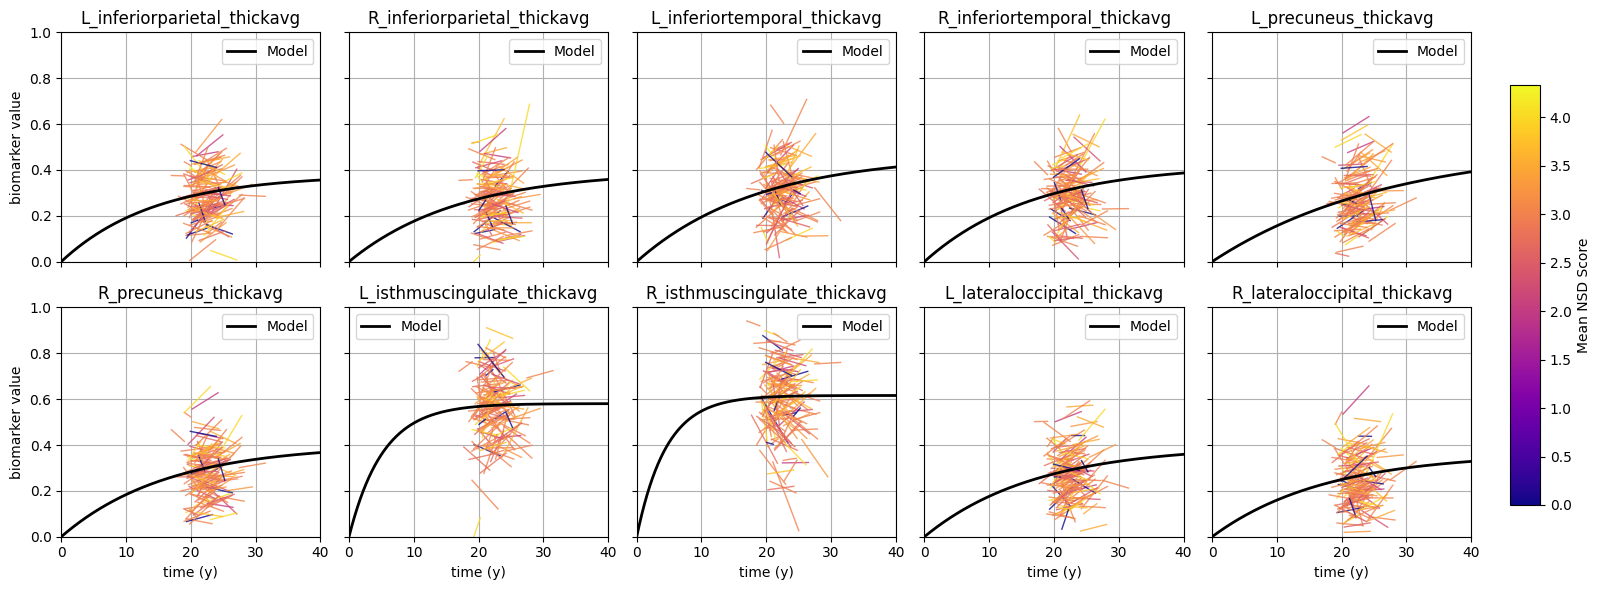

<Figure size 640x480 with 0 Axes>

In [39]:
# Spaghetti plot for NSD - ROI regions (adapted from NHY function)
from sklearn.linear_model import LinearRegression
import matplotlib.cm as cm
import matplotlib.colors as colors

def plot_all_patient_regression_lines_grid_nsd(X, dt, ids, beta, t_span, nsd, model=None,
                                               biomarker_indices=None, biomarker_labels=None,
                                               max_lines=500, t_max=40):
    """
    Plot regression lines per patient for each selected biomarker on a grid of subplots.
    Each line is color-coded by the patient's mean NSD score.
    """
    if biomarker_indices is None:
        biomarker_indices = list(range(X.shape[1]))

    unique_ids = np.unique(ids)
    pid_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    # compute mean NSD score per patient
    mean_nsd = {}
    for pid in unique_ids:
        nsd_i = nsd[ids == pid]
        valid_nsd = nsd_i[~np.isnan(nsd_i)]
        mean_nsd[pid] = np.mean(valid_nsd) if len(valid_nsd) > 0 else np.nan

    # colormap setup
    cmap = cm.plasma
    nsd_vals = np.array([v for v in mean_nsd.values() if not np.isnan(v)])
    if len(nsd_vals) > 0:
        norm = colors.Normalize(vmin=np.nanmin(nsd_vals), vmax=np.nanmax(nsd_vals))
    else:
        norm = colors.Normalize(vmin=0, vmax=1)

    n_plots = len(biomarker_indices)
    n_cols = 5
    n_rows = 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), squeeze=True)
    axes = axes.flatten()

    for plot_idx, j in enumerate(biomarker_indices):
        ax = axes[plot_idx]
        title = biomarker_labels[j] if biomarker_labels else f"biomarker {j}"
        ax.set_title(f"{title}")
        
        line_count = 0
        for pid in unique_ids:
            if line_count >= max_lines:
                break
            mask = (ids == pid)
            if np.sum(mask) < 2:
                continue

            X_i = X[mask, j]
            dt_i = dt[mask]
            beta_i = beta[pid_to_index[pid]]
            t_ij = dt_i + beta_i

            nsd_mean = mean_nsd[pid]
            if np.isnan(nsd_mean):
                continue
            line_color = cmap(norm(nsd_mean))

            model_i = LinearRegression().fit(t_ij.reshape(-1, 1), X_i)
            t_fit = np.linspace(t_ij.min(), t_ij.max(), 20)
            x_fit = model_i.predict(t_fit.reshape(-1, 1))

            ax.plot(t_fit, x_fit, color=line_color, alpha=0.8, linewidth=1)
            line_count += 1

        # plot model-predicted trajectory
        if model is not None:
            ax.plot(t_span, model[j], color='black', linewidth=2, label="Model")
            ax.legend()
            
        # determine subplot grid position
        row_idx = plot_idx // n_cols
        col_idx = plot_idx % n_cols

        # only show x-labels on bottom row
        if row_idx == n_rows - 1:
            ax.set_xlabel("time (y)")
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)

        # only show y-labels on leftmost column
        if col_idx == 0:
            ax.set_ylabel("biomarker value")
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

        ax.set_ylim(0, 1)
        ax.grid(True)
        ax.set_xlim(0, t_max)

    # remove unused axes
    for k in range(n_plots, len(axes)):
        fig.delaxes(axes[k])

    # Add colorbar for NSD scale
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([1.01, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Mean NSD Score")
    
    plt.tight_layout()
    plt.show()

# Plot NSD spaghetti plot
plt.figure(figsize=(15, 7))
plot_all_patient_regression_lines_grid_nsd(
    X=X_obs_best,
    dt=dt_best,
    ids=ids_best,
    beta=beta_best,
    t_span=t_span,
    nsd=nsd_best,
    model=Xtraj_best,
    biomarker_indices=ROI,
    biomarker_labels=biomarker_names,
    max_lines=500,
    t_max=t_span[-1]
)
plt.suptitle(f"Best Model (LSE={best_row['final_lse']:.3f}) - NSD Colored Spaghetti Plot - ROI Regions", y=1.02)
plt.show()
